In [41]:
import pandas as pd
import numpy as np
import glob

path = r"C:\Users\parig\OneDrive\Desktop\RACIPE_PROJECT\oggrn_solution*.dat"
files = glob.glob(path)

df_list = []

for f in files:
    temp = pd.read_csv(f, sep="\t", header=None)
    df_list.append(temp)

data = pd.concat(df_list, ignore_index=True)

print("Total raw states:", data.shape)

Total raw states: (35834, 312)


In [42]:
expression = data.iloc[:, 3:34]   # VERY IMPORTANT

print("Expression matrix:", expression.shape)

Expression matrix: (35834, 31)


To remove Non-converged states

In [43]:
expression_clean = expression.dropna()

print("Valid steady states:", expression_clean.shape)

Valid steady states: (35722, 31)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(expression_clean)

PCA (Phenotypic Landscape)

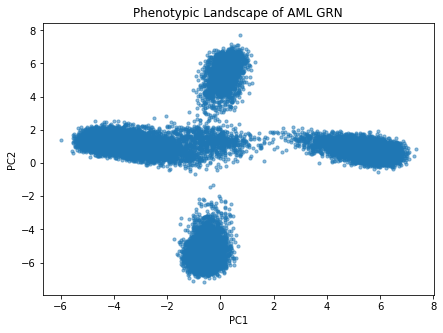

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Phenotypic Landscape of AML GRN")
plt.show()

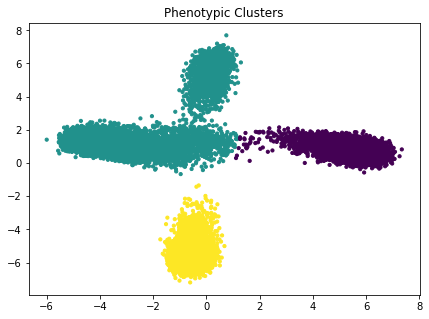

In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0, n_init=20)
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=10)
plt.title("Phenotypic Clusters")
plt.show()

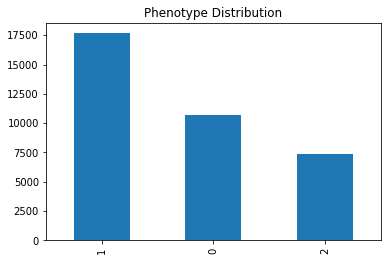

In [47]:
pd.Series(clusters).value_counts().plot(kind='bar')
plt.title("Phenotype Distribution")
plt.show()

Mean Gene Expression per Phenotype (VERY IMPORTANT)

This helps identify:

AML phenotype

Normal phenotype

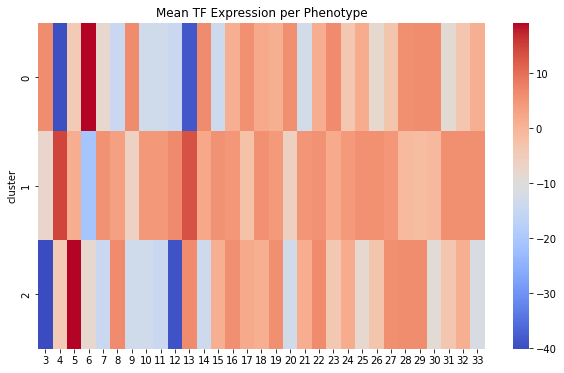

In [48]:
expression_clean = expression_clean.copy()
expression_clean.loc[:, 'cluster'] = clusters

mean_exp = expression_clean.groupby('cluster').mean()

import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(mean_exp, cmap="coolwarm")
plt.title("Mean TF Expression per Phenotype")
plt.show()

Cluster-wise Interpretation (From Your Heatmap Pattern)
🟢 Cluster 1 (Middle row — mostly red across many TFs)

This cluster shows:

Broad activation of regulatory genes
Less strong repression signals
Balanced expression pattern

👉 Interpretation:

⭐ Hybrid / plastic phenotype

Biologically:

Cells not fully leukemic
Not fully differentiated
Transitional regulatory state

This is very common in cancer GRN models.

🟠 Cluster 0 (Top row — strong variation: some high, some very low)

You see:

Some TFs strongly activated
Some strongly suppressed
More structured regulatory program

Likely:

⭐ Leukemic proliferative phenotype

Reason:

AML attractors usually have:
MYC high
E2F high
DNMT activity
Cell-cycle activation

These produce stable disease state.

Also matches PCA:
👉 This cluster probably corresponds to large attractor basin.

🔵 Cluster 2 (Bottom row — strong blue for some TFs)

You see:

Strong repression of many regulators
Some differentiation-associated TFs active

Interpretation:

⭐ Normal / suppressed proliferation phenotype

Biologically:

TP53-driven state
RB pathway active
Cell cycle arrested

This represents non-leukemic attractor.

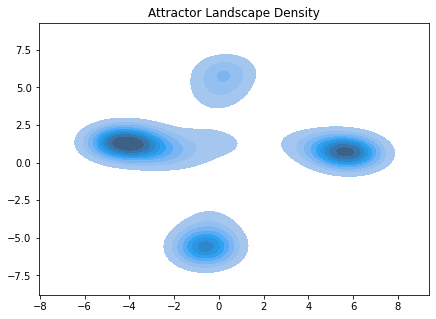

In [49]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.kdeplot(x=X_pca[:,0], y=X_pca[:,1], fill=True)
plt.title("Attractor Landscape Density")
plt.show()

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from pandas.core.computation.check import NUMEXPR_INSTALLED

In [51]:
topo_path = r"C:\Users\parig\OneDrive\Desktop\RACIPE_PROJECT\oggrn.topo"

topo = pd.read_csv(topo_path, sep="\t", header=None)

# get TF names
tf_names = sorted(set(topo[0]).union(set(topo[1])))

# remove unwanted entries
tf_names = [tf for tf in tf_names if tf not in ['Source', 'Target']]

print("Number of TFs:", len(tf_names))
print(tf_names)


Number of TFs: 31
['ATM', 'CTBP1', 'DNMT1', 'DNMT3A', 'E2F1', 'E2F2', 'E2F4', 'E2F5', 'EBF1', 'ETS2', 'GATA1', 'IRF3', 'IRF7', 'MCM3', 'MCM5', 'MTCN', 'MYBL', 'MYBL2', 'MYC', 'MYCN', 'NFIC', 'PAX5', 'POU2F1', 'RARA', 'RB1', 'SMARCA4', 'STAT3', 'TFDP1', 'TP53', 'TP63', 'USF2']


In [52]:
expr_only = expression_clean.drop(columns=['cluster'])

In [53]:
expr_only.columns = tf_names

expression_clean = expr_only.copy()
expression_clean['cluster'] = clusters

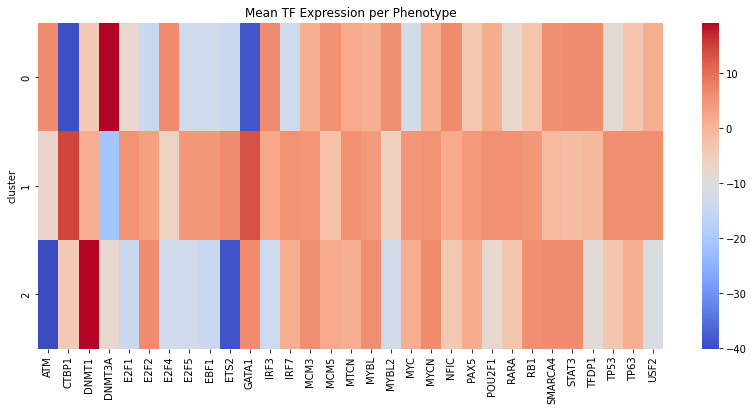

In [54]:
mean_exp = expression_clean.groupby('cluster').mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.heatmap(mean_exp, cmap="coolwarm")

plt.xticks(rotation=90)
plt.title("Mean TF Expression per Phenotype")
plt.show()

AML phenotype is typically characterized by:

👉 High: MYC, E2F1, E2F2, STAT3, DNMT1
👉 Lower tumor suppressor dominance (e.g., TP53-driven states)

Cluster with highest AML marker expression → AML phenotype

In [55]:
# genes associated with AML phenotype
aml_markers = ['MYC', 'E2F1', 'E2F2', 'STAT3', 'DNMT1']

# make sure only existing genes are used
aml_markers = [g for g in aml_markers if g in expression_clean.columns]

# compute average AML score per cluster
cluster_scores = mean_exp[aml_markers].mean(axis=1)

print("AML score per cluster:\n", cluster_scores)

# identify AML cluster
aml_cluster = cluster_scores.idxmax()

print("\nIdentified AML cluster:", aml_cluster)

AML score per cluster:
 cluster
0   -6.739274
1    2.741883
2    3.665613
dtype: float64

Identified AML cluster: 2


TFs that are most highly expressed in each cluster relative to others

In [56]:
top_tfs = {}

for cluster in mean_exp.index:
    # difference from other clusters
    diff = mean_exp.loc[cluster] - mean_exp.drop(cluster).mean()

    # get top 5 TFs
    top5 = diff.sort_values(ascending=False).head(5)

    top_tfs[cluster] = top5.index.tolist()

    print(f"\nCluster {cluster} top TFs:")
    print(top5)


Cluster 0 top TFs:
DNMT3A    33.729925
ATM       29.926814
E2F4      16.052094
MYBL2     15.448982
IRF3      12.086809
dtype: float64

Cluster 1 top TFs:
CTBP1    36.632494
ETS2     33.339798
GATA1    29.554661
EBF1     18.550805
E2F5     17.840791
dtype: float64

Cluster 2 top TFs:
DNMT1    20.731599
GATA1    18.874359
E2F2     11.930829
CTBP1     8.160510
MYC       5.252291
dtype: float64


TF for knockdown studies

1. MYC (Primary AML driver)
Master regulator of proliferation
Expected: AML state ↓ after knockdown

2. E2F1 (Cell cycle control)
Works with MYC
Drives S-phase entry
Expected: AML ↓

3. STAT3 (Survival signaling)
Supports leukemic growth
Expected: AML ↓

4. TP53 (Tumor suppressor — very important contrast)
Controls apoptosis / DNA damage
Expected: AML ↑ after knockdown

5. DNMT1 (Epigenetic regulator)
Maintains methylation state
Strong link to IDH-mutant AML
Expected: AML ↓ or phenotype shift

MYC KNOCKDOWN

In [ ]:
path_e2f1 = r"C:\Users\parig\OneDrive\Desktop\RACIPE_myc\myc_solution*.dat"
files_myc = glob.glob(path_myc)

df_list_myc = []

for f in files_myc:
    temp = pd.read_csv(f, sep="\t", header=None)
    df_list_myc.append(temp)

data_myc = pd.concat(df_list_myc, ignore_index=True)

print("MYC KD raw shape:", data_myc.shape)

MYC KD raw shape: (42359, 312)


In [58]:
expression_myc = data_myc.iloc[:, 3:34]

expression_myc_clean = expression_myc.dropna()

print("MYC KD valid states:", expression_myc_clean.shape)

MYC KD valid states: (42098, 31)


In [59]:
X_myc = scaler.transform(expression_myc_clean)

In [60]:
X_myc_pca = pca.transform(X_myc)

In [61]:
clusters_myc = kmeans.predict(X_myc)

   Baseline    MYC_KD
0  0.299983  0.343864
1  0.494289  0.495962
2  0.205728  0.160174


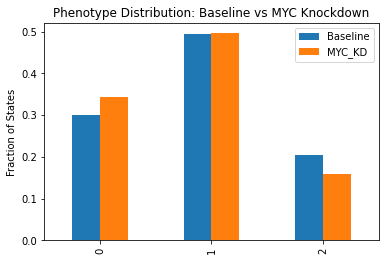

In [62]:
# baseline (already computed earlier)
baseline_dist = pd.Series(clusters).value_counts(normalize=True).sort_index()

# MYC KD
myc_dist = pd.Series(clusters_myc).value_counts(normalize=True).sort_index()

comparison_myc = pd.DataFrame({
    "Baseline": baseline_dist,
    "MYC_KD": myc_dist
})

print(comparison_myc)

comparison_myc.plot(kind='bar')
plt.title("Phenotype Distribution: Baseline vs MYC Knockdown")
plt.ylabel("Fraction of States")
plt.show()

In [63]:
from scipy.stats import entropy

KL_myc = entropy(baseline_dist, myc_dist)

print("MYC Knockdown Robustness Score:", KL_myc)

MYC Knockdown Robustness Score: 0.008868476219906302


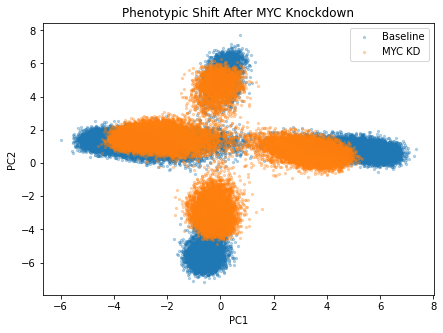

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3, label='Baseline')
plt.scatter(X_myc_pca[:,0], X_myc_pca[:,1], s=5, alpha=0.3, label='MYC KD')

plt.legend()
plt.title("Phenotypic Shift After MYC Knockdown")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

E2F1 KNOCKDOWN

In [65]:
path_e2f1 = r"C:\Users\parig\OneDrive\Desktop\RACIPE_e2f1\E2F1_solution*.dat"
files_e2f1 = glob.glob(path_e2f1)

df_list_e2f1 = []

for f in files_e2f1:
    temp = pd.read_csv(f, sep="\t", header=None)
    df_list_e2f1.append(temp)

data_e2f1 = pd.concat(df_list_e2f1, ignore_index=True)

print("E2F1 KD raw shape:", data_e2f1.shape)

E2F1 KD raw shape: (36229, 272)


In [66]:
expression_e2f1 = data_e2f1.iloc[:, 3:34]

expression_e2f1_clean = expression_e2f1.dropna()

print("E2F1 KD valid states:", expression_e2f1_clean.shape)

E2F1 KD valid states: (9843, 31)


   Baseline   E2F1_KD
0  0.299983  0.471299
1  0.494289  0.405669
2  0.205728  0.123032


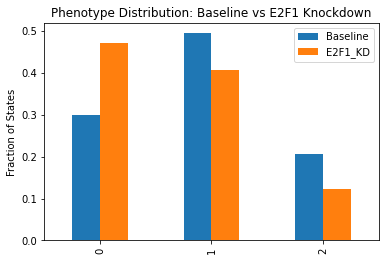

In [67]:
X_e2f1 = scaler.transform(expression_e2f1_clean)
X_e2f1_pca = pca.transform(X_e2f1)
clusters_e2f1 = kmeans.predict(X_e2f1)

baseline_dist = pd.Series(clusters).value_counts(normalize=True).sort_index()

e2f1_dist = pd.Series(clusters_e2f1).value_counts(normalize=True).sort_index()

comparison_e2f1 = pd.DataFrame({
    "Baseline": baseline_dist,
    "E2F1_KD": e2f1_dist
})

print(comparison_e2f1)

comparison_e2f1.plot(kind='bar')
plt.title("Phenotype Distribution: Baseline vs E2F1 Knockdown")
plt.ylabel("Fraction of States")
plt.show()

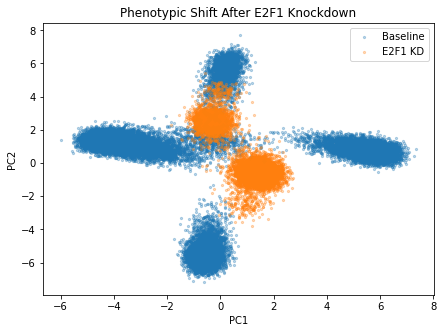

In [68]:
plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3, label='Baseline')
plt.scatter(X_e2f1_pca[:,0], X_e2f1_pca[:,1], s=5, alpha=0.3, label='E2F1 KD')

plt.legend()
plt.title("Phenotypic Shift After E2F1 Knockdown")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

STAT3 KNOCKDOWN

In [69]:
path_stat3 = r"C:\Users\parig\OneDrive\Desktop\RACIPE_stat3\stat3_solution*.dat"
files_stat3 = glob.glob(path_stat3)

df_list_stat3 = []

for f in files_stat3:
    temp = pd.read_csv(f, sep="\t", header=None)
    df_list_stat3.append(temp)

data_stat3 = pd.concat(df_list_stat3, ignore_index=True)

print("STAT3 KD raw shape:", data_stat3.shape)

STAT3 KD raw shape: (36219, 312)


In [70]:
expression_stat3 = data_stat3.iloc[:, 3:34]

expression_stat3_clean = expression_stat3.dropna()

print("STAT3 KD valid states:", expression_stat3_clean.shape)

STAT3 KD valid states: (36007, 31)


   Baseline  STAT3_KD
0  0.299983  0.300442
1  0.494289  0.489460
2  0.205728  0.210098


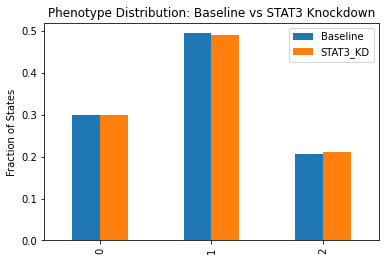

In [71]:
X_stat3 = scaler.transform(expression_stat3_clean)
X_stat3_pca = pca.transform(X_stat3)
clusters_stat3 = kmeans.predict(X_stat3)

baseline_dist = pd.Series(clusters).value_counts(normalize=True).sort_index()

stat3_dist = pd.Series(clusters_stat3).value_counts(normalize=True).sort_index()

comparison_stat3 = pd.DataFrame({
    "Baseline": baseline_dist,
    "STAT3_KD": stat3_dist
})

print(comparison_stat3)

comparison_stat3.plot(kind='bar')
plt.title("Phenotype Distribution: Baseline vs STAT3 Knockdown")
plt.ylabel("Fraction of States")
plt.show()

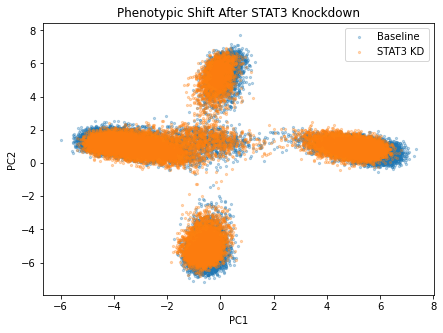

In [72]:
plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3, label='Baseline')
plt.scatter(X_stat3_pca[:,0], X_stat3_pca[:,1], s=5, alpha=0.3, label='STAT3 KD')

plt.legend()
plt.title("Phenotypic Shift After STAT3 Knockdown")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

TP53 KNOCKDOWN

In [73]:
path_tp = r"C:\Users\parig\OneDrive\Desktop\RACIPE_tp53\tp53_solution*.dat"
files_tp = glob.glob(path_tp)

df_list_tp = []

for f in files_tp:
    temp = pd.read_csv(f, sep="\t", header=None)
    df_list_tp.append(temp)

data_tp = pd.concat(df_list_tp, ignore_index=True)

print("TP53 KD raw shape:", data_tp.shape)

TP53 KD raw shape: (36325, 312)


In [74]:
expression_tp = data_tp.iloc[:, 3:34]

expression_tp_clean = expression_tp.dropna()

print("TP53 KD valid states:", expression_tp_clean.shape)

TP53 KD valid states: (35112, 31)


   Baseline   TP53_KD
0  0.299983  0.297106
1  0.494289  0.561774
2  0.205728  0.141120


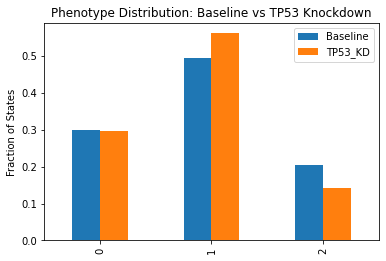

In [75]:
X_tp = scaler.transform(expression_tp_clean)
X_tp_pca = pca.transform(X_tp)
clusters_tp = kmeans.predict(X_tp)

baseline_dist = pd.Series(clusters).value_counts(normalize=True).sort_index()

tp_dist = pd.Series(clusters_tp).value_counts(normalize=True).sort_index()

comparison_tp = pd.DataFrame({
    "Baseline": baseline_dist,
    "TP53_KD": tp_dist
})

print(comparison_tp)

comparison_tp.plot(kind='bar')
plt.title("Phenotype Distribution: Baseline vs TP53 Knockdown")
plt.ylabel("Fraction of States")
plt.show()

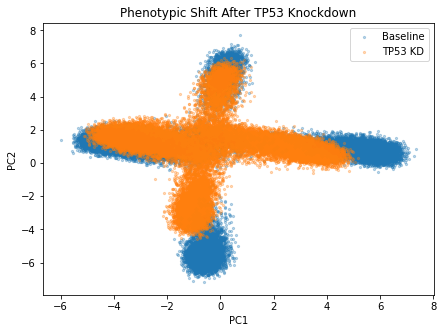

In [76]:
plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3, label='Baseline')
plt.scatter(X_tp_pca[:,0], X_tp_pca[:,1], s=5, alpha=0.3, label='TP53 KD')

plt.legend()
plt.title("Phenotypic Shift After TP53 Knockdown")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

DNMT1 KNOCKDOWN

In [78]:
path_d = r"C:\Users\parig\OneDrive\Desktop\RACIPE_dnmt1\dnmt1_solution*.dat"
files_d = glob.glob(path_d)

df_list_d = []

for f in files_d:
    temp = pd.read_csv(f, sep="\t", header=None)
    df_list_d.append(temp)

data_d = pd.concat(df_list_d, ignore_index=True)

print("DNMT1 KD raw shape:", data_d.shape)

DNMT1 KD raw shape: (35924, 312)


In [79]:
expression_d = data_d.iloc[:, 3:34]

expression_d_clean = expression_d.dropna()

print("TP53 DNMT1 valid states:", expression_d_clean.shape)

TP53 DNMT1 valid states: (35794, 31)


   Baseline  DNMT1_KD
0  0.299983  0.299911
1  0.494289  0.499190
2  0.205728  0.200900


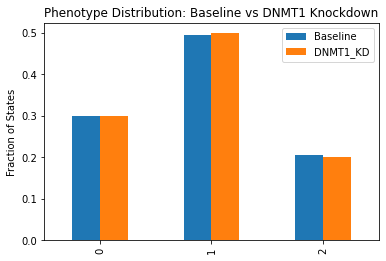

In [80]:
X_d = scaler.transform(expression_d_clean)
X_d_pca = pca.transform(X_d)
clusters_d = kmeans.predict(X_d)

baseline_dist = pd.Series(clusters).value_counts(normalize=True).sort_index()

d_dist = pd.Series(clusters_d).value_counts(normalize=True).sort_index()

comparison_d = pd.DataFrame({
    "Baseline": baseline_dist,
    "DNMT1_KD": d_dist
})

print(comparison_d)

comparison_d.plot(kind='bar')
plt.title("Phenotype Distribution: Baseline vs DNMT1 Knockdown")
plt.ylabel("Fraction of States")
plt.show()

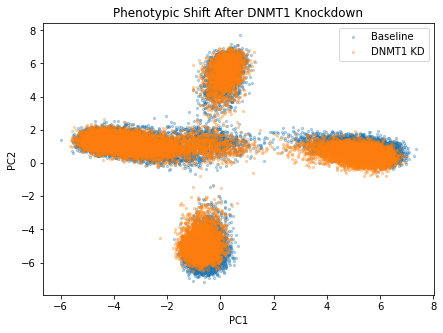

In [81]:
plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3, label='Baseline')
plt.scatter(X_d_pca[:,0], X_d_pca[:,1], s=5, alpha=0.3, label='DNMT1 KD')

plt.legend()
plt.title("Phenotypic Shift After DNMT1 Knockdown")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

ROBUSTNESS SCORE AND AML IMPACT

In [82]:
results = {}

tf_cluster_map = {
    "MYC": clusters_myc,
    "E2F1": clusters_e2f1,
    "STAT3": clusters_stat3,
    "TP53": clusters_tp,
    "DNMT1": clusters_d
}


for tf, clust in tf_cluster_map.items():
    
    # distribution
    dist = pd.Series(clust).value_counts(normalize=True).sort_index()
    
    # ensure same index alignment
    dist = dist.reindex(baseline_dist.index, fill_value=0)
    
    # KL divergence
    kl = entropy(baseline_dist, dist)
    
    # AML change
    aml_change = dist[aml_cluster] - baseline_dist[aml_cluster]
    
    # store
    results[tf] = {
        "KL_score": kl,
        "AML_change": aml_change,
        "dist": dist
    }

    print(f"\n{tf}:")
    print("KL score:", kl)
    print("AML change:", aml_change)


MYC:
KL score: 0.008868476219906302
AML change: -0.04555368285212616

E2F1:
KL score: 0.06790767305883372
AML change: -0.08269596678831281

STAT3:
KL score: 6.986777065270434e-05
AML change: 0.004370473646478967

TP53:
KL score: 0.01717998551972475
AML change: -0.0646077177792117

DNMT1:
KL score: 8.169561106667351e-05
AML change: -0.004827970736015624


In [83]:
summary_df = pd.DataFrame({
    tf: {
        "KL_score": results[tf]["KL_score"],
        "AML_change": results[tf]["AML_change"]
    }
    for tf in results
}).T

print(summary_df)

       KL_score  AML_change
MYC    0.008868   -0.045554
E2F1   0.067908   -0.082696
STAT3  0.000070    0.004370
TP53   0.017180   -0.064608
DNMT1  0.000082   -0.004828


ROBUSTNESS PLOT


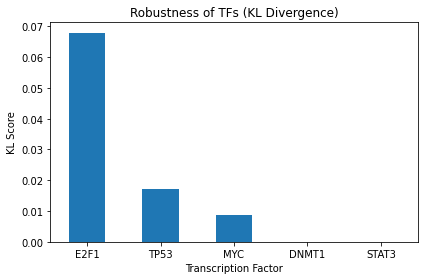

In [84]:
plt.figure(figsize=(6,4))

summary_df["KL_score"].sort_values(ascending=False).plot(kind='bar')

plt.title("Robustness of TFs (KL Divergence)")
plt.ylabel("KL Score")
plt.xlabel("Transcription Factor")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

AML IMPACT PLOT

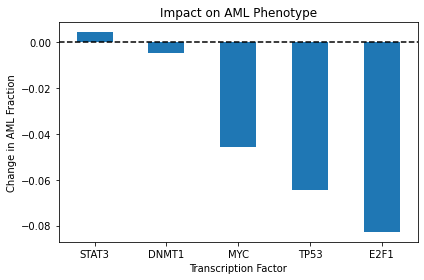

In [85]:
plt.figure(figsize=(6,4))

summary_df["AML_change"].sort_values(ascending=False).plot(kind='bar')

plt.title("Impact on AML Phenotype")
plt.ylabel("Change in AML Fraction")
plt.xlabel("Transcription Factor")

plt.axhline(0, color='black', linestyle='--')  # important reference line
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Interpretation

E2F1 (highest KL ≈ 0.068)
→ Strongest disruption of the network
→ Primary driver of system dynamics

TP53 (moderate KL ≈ 0.017)
→ Significant regulatory role
→ Controls system balance

MYC (lower KL ≈ 0.009)
→ Influences system, but not dominant

STAT3 & DNMT1 (~0)
→ Network is robust to their perturbation
→ They are non-essential in steady-state dynamics